# 上机实践02 信息2301 2310650118 洪菁曼

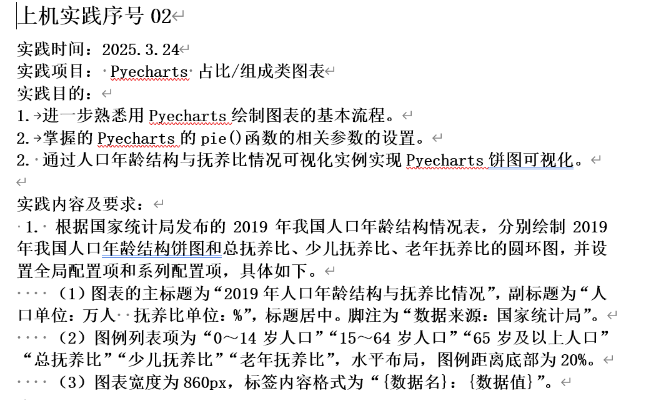

In [3]:
from pyecharts_exporter import display_chart, get_chart_urls

In [4]:
from pyecharts import options as opts
from pyecharts.charts import Pie, Grid
import pandas as pd
from pyecharts.globals import ThemeType

#导入数据
df = pd.read_csv('./data/人口年龄结构.csv', encoding='gbk')
df

,指标,2019年,2018年,2017年,2016年,2015年,2014年,2013年,2012年
0,年末总人口(万人),141008.0,140541.0,140011.0,139232.0,138326.0,137646.0,136726.0,135922.0
1,0-14岁人口(万人),23689.0,23751.0,23522.0,23252.0,22824.0,22712.0,22423.0,22427.0
2,15-64岁人口(万人),99552.0,100065.0,100528.0,100943.0,100978.0,101032.0,101041.0,100718.0
3,65岁及以上人口(万人),17767.0,16724.0,15961.0,15037.0,14524.0,13902.0,13262.0,12777.0
4,总抚养比(%),41.5,40.4,39.3,37.9,37.0,36.2,35.3,34.9
5,少儿抚养比(%),23.8,23.7,23.4,22.9,22.6,22.5,22.2,22.2
6,老年抚养比(%),17.8,16.8,15.9,15.0,14.3,13.7,13.1,12.7
7,注：1.1981年及以前人口数据为户籍统计数；1982、1990、2000、2010、202...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2.总人口和按性别分人口中包括现役军人，按城乡分人口中现役军人计入城镇人口。,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,数据来源：国家统计局,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# 提取2019年的数据
year_2019 = df['2019年']

# 获取人口年龄结构数据
population_data = [
    list(year_2019[df['指标'] == '0-14岁人口(万人)'].values),
    list(year_2019[df['指标'] == '15-64岁人口(万人)'].values),
    list(year_2019[df['指标'] == '65岁及以上人口(万人)'].values)
]

population_values = [int(p[0]) for p in population_data if p]
population_names = ['0～14岁人口', '15～64岁人口', '65岁及以上人口']

# 获取抚养比数据
dependency_data = [
    list(year_2019[df['指标'] == '总抚养比(%)'].values),
    list(year_2019[df['指标'] == '少儿抚养比(%)'].values),
    list(year_2019[df['指标'] == '老年抚养比(%)'].values)
]

dependency_values = [float(d[0]) for d in dependency_data if d]
dependency_names = ['总抚养比', '少儿抚养比', '老年抚养比']

# 创建饼图
pie = (
    Pie(init_opts=opts.InitOpts(theme=ThemeType.LIGHT))
    .add(
        series_name="人口年龄结构",
        data_pair=[(population_names[i], population_values[i]) for i in range(len(population_names))],
        radius=["0%", "35%"],
        center=["25%", "40%"],
        label_opts=opts.LabelOpts(
            formatter="{b}：\n{c}万人({d}%)",
            position="outside"
        )
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="2019年人口年龄结构与抚养比情况",
            subtitle="人口单位：万人  抚养比单位：%",
            pos_left="center",
            pos_top="5%",
            title_textstyle_opts=opts.TextStyleOpts(font_size=16),
            subtitle_textstyle_opts=opts.TextStyleOpts(font_size=11, color="gray")
        ),
        legend_opts=opts.LegendOpts(
            orient="horizontal",
            pos_bottom="20%",
            pos_right="50%",
            item_width=20
        ),
        tooltip_opts=opts.TooltipOpts(
            formatter="{b}：{c}万人 ({d}%)",
            trigger="item"
        )
    )
    .set_series_opts(
        tooltip_opts=opts.TooltipOpts(
            formatter="{b}：{c}万人 ({d}%)"
        )
    )
)

# 创建圆环图
ring = (
    Pie(init_opts=opts.InitOpts(theme=ThemeType.LIGHT))
    .add(
        series_name="抚养比",
        data_pair=[(dependency_names[i], dependency_values[i]) for i in range(len(dependency_names))],
        radius=["20%", "35%"],
        center=["75%", "40%"],
        label_opts=opts.LabelOpts(
            formatter="{b}：\n{c}%",
            position="outside"
        )
    )
    .set_global_opts(
        legend_opts=opts.LegendOpts(
            orient="horizontal",
            pos_bottom="20%",
            pos_left="50%",
            item_width=20
        ),
        tooltip_opts=opts.TooltipOpts(
            formatter="{b}：{c}%",
            trigger="item"
        )
    )
    .set_series_opts(
        tooltip_opts=opts.TooltipOpts(
            formatter="{b}：{c}%"
        )
    )
)

# 组合图表
grid = (
    Grid(init_opts=opts.InitOpts(width="860px", height="600px", theme=ThemeType.LIGHT))
    .add(pie, grid_opts=opts.GridOpts())
    .add(ring, grid_opts=opts.GridOpts())
)


display_chart(grid)


In [10]:
!jupyter nbconvert --to html 上机实践02.ipynb

[NbConvertApp] Converting notebook 上机实践02.ipynb to html
[NbConvertApp] Writing 478277 bytes to 上机实践02.html
